In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import xgboost, catboost, lightgbm,shap, optuna
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = pd.read_csv(r'../data/wnba_players_data.csv')
data.drop(columns=['Unnamed: 0'], inplace=True)
data.head()

,Season,Player,G,MP,GS,FG,FGA,FG%,3P,3PA,...,USG%,ORtg,DRtg,OWS,DWS,WS,WS/40,PLUS_MINUS,award_share,is_mvp
0,1997,Anita Maxwell,9,63,0,8,25,0.320,0,0,...,25.6,72.0,89.0,-0.2,0.1,-0.1,-0.036,-5,0.0,0
1,1997,Tammi Reiss,28,831,26,72,231,0.312,30,101,...,17.0,87.0,105.0,0.2,-0.7,-0.5,-0.024,-288,0.0,0
2,1997,Catarina Pollini,13,94,0,8,22,0.364,0,0,...,17.6,77.0,92.0,-0.1,0.1,0.0,0.005,19,0.0,0
3,1997,Bridget Pettis,28,842,28,107,320,0.334,41,134,...,24.0,94.0,88.0,1.5,1.7,3.2,0.151,91,0.0,0
4,1997,Kim Perrot,28,692,24,59,162,0.364,28,99,...,16.5,87.0,87.0,0.2,1.5,1.7,0.098,155,0.0,0


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4691 entries, 0 to 4690
Data columns (total 46 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Season       4691 non-null   int64  
 1   Player       4691 non-null   str    
 2   G            4691 non-null   int64  
 3   MP           4691 non-null   int64  
 4   GS           4691 non-null   int64  
 5   FG           4691 non-null   int64  
 6   FGA          4691 non-null   int64  
 7   FG%          4691 non-null   float64
 8   3P           4691 non-null   int64  
 9   3PA          4691 non-null   int64  
 10  3P%          4691 non-null   float64
 11  2P           4691 non-null   int64  
 12  2PA          4691 non-null   int64  
 13  2P%          4691 non-null   float64
 14  FT           4691 non-null   int64  
 15  FTA          4691 non-null   int64  
 16  FT%          4691 non-null   float64
 17  ORB          4691 non-null   int64  
 18  TRB          4691 non-null   int64  
 19  AST          4691

In [4]:
data.isna().sum()

Season         0
Player         0
G              0
MP             0
GS             0
FG             0
FGA            0
FG%            0
3P             0
3PA            0
3P%            0
2P             0
2PA            0
2P%            0
FT             0
FTA            0
FT%            0
ORB            0
TRB            0
AST            0
STL            0
BLK            0
TOV            0
PF             0
PTS            0
PER            0
TS%            0
eFG%           0
3PAr           0
FTr            0
ORB%           0
TRB%           0
AST%           0
STL%           0
BLK%           0
TOV%           0
USG%           0
ORtg           0
DRtg           0
OWS            0
DWS            0
WS             0
WS/40          0
PLUS_MINUS     0
award_share    0
is_mvp         0
dtype: int64

In [5]:
data.columns

Index(['Season', 'Player', 'G', 'MP', 'GS', 'FG', 'FGA', 'FG%', '3P', '3PA',
       '3P%', '2P', '2PA', '2P%', 'FT', 'FTA', 'FT%', 'ORB', 'TRB', 'AST',
       'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PER', 'TS%', 'eFG%', '3PAr', 'FTr',
       'ORB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%', 'ORtg', 'DRtg',
       'OWS', 'DWS', 'WS', 'WS/40', 'PLUS_MINUS', 'award_share', 'is_mvp'],
      dtype='str')

In [6]:
df = pd.DataFrame()
# subset important features
# features that show players skill level as well as their impact on the court
df = data[['Season', 'Player', 'TS%','WS', 'PER', 'USG%','PLUS_MINUS','award_share','is_mvp']]
df['pts_per_game'] = data['PTS'] / data['G']
df['stl_per_game'] = data['STL'] / data['G']
df['ast_per_game'] = data['AST'] / data['G']
df['trb_per_game'] = data['TRB'] / data['G']
df['blk_per_game'] = data['BLK'] / data['G']

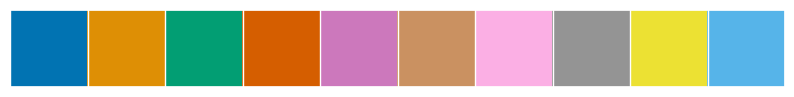

In [7]:
sns.set_style('darkgrid')
sns.set_palette('colorblind')
sns.set(font_scale=0.8)

palette = sns.color_palette('colorblind')
sns.palplot(palette)

Explarotary Data Analysis

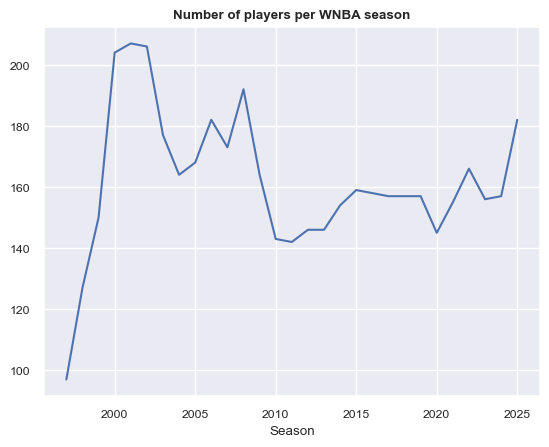

In [8]:
df['Season'].value_counts(sort=False).plot.line()
plt.title("Number of players per WNBA season", fontweight='bold')
plt.show()

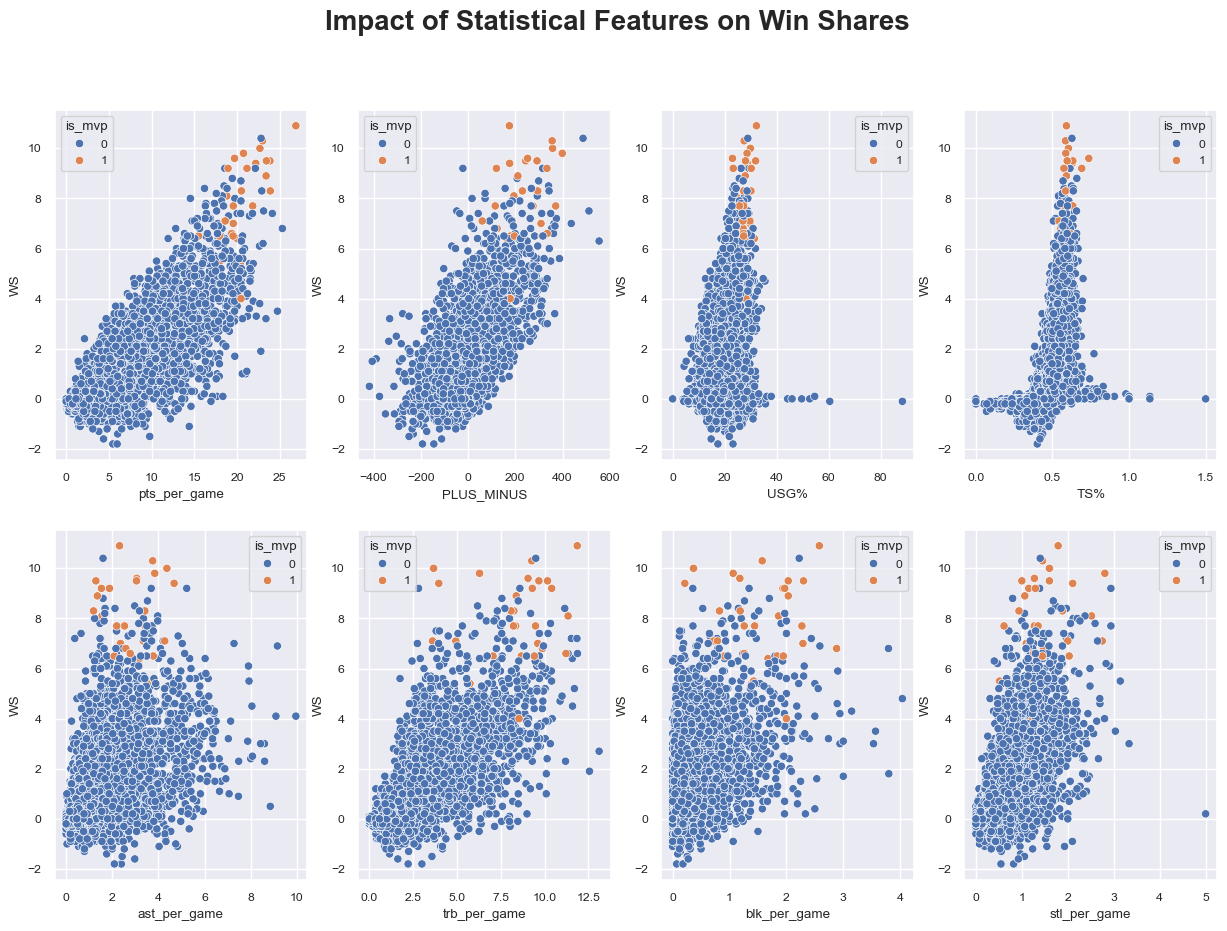

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(15,10))
sns.scatterplot(
    data=df,
    hue='is_mvp',
    x='pts_per_game',
    y='WS',
    ax=axes[0,0]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    x='PLUS_MINUS',
    y='WS',
    ax=axes[0,1]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    y='WS',
    x='USG%',
    ax=axes[0,2]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    x='TS%',
    y='WS',
    ax=axes[0,3]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    y='WS',
    x='ast_per_game',
    ax=axes[1,0]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    y='WS',
    x='trb_per_game',
    ax=axes[1,1]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    y='WS',
    x='blk_per_game',
    ax=axes[1,2]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    y='WS',
    x='stl_per_game',
    ax=axes[1,3]
)
fig.suptitle('Impact of Statistical Features on Win Shares', fontsize=20, fontweight='bold')
plt.show()

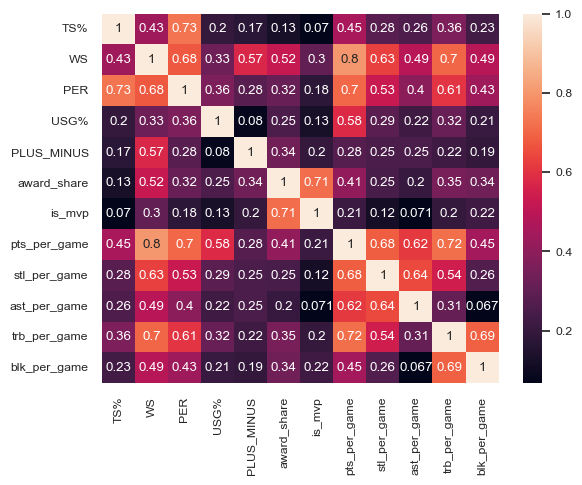

In [10]:
sns.heatmap(data=df[df.columns[2:]].corr(), annot=True)
plt.show()

Award share is highly correlated WS, that means player who contribute to their teams total wins have a higher chance of getting MVP votes 

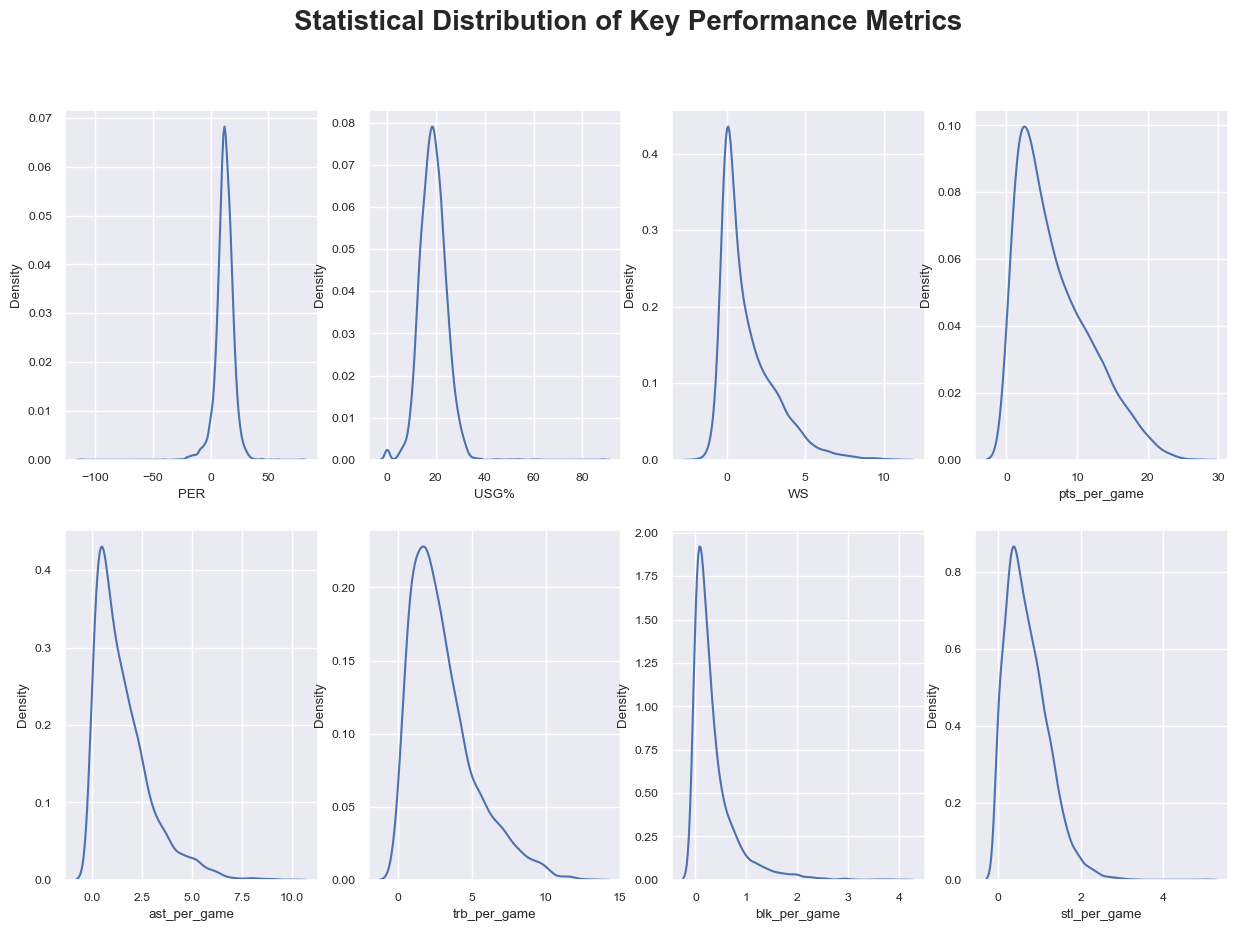

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(15,10))
sns.kdeplot(
    data=df,
    x='PER',
    ax=axes[0,0]
)
sns.kdeplot(
    data=df,
    x='USG%',
    ax=axes[0,1]
)
sns.kdeplot(
    data=df,
    x='WS',
    ax=axes[0,2]
)
sns.kdeplot(
    data=df,
    x='pts_per_game',
    ax=axes[0,3]
)
sns.kdeplot(
    data=df,
    x='ast_per_game',
    ax=axes[1,0]
)
sns.kdeplot(
    data=df,
    x='trb_per_game',
    ax=axes[1,1]
)
sns.kdeplot(
    data=df,
    x='blk_per_game',
    ax=axes[1,2]
)
sns.kdeplot(
    data=df,
    x='stl_per_game',
    ax=axes[1,3]
)
fig.suptitle('Statistical Distribution of Key Performance Metrics', fontsize=20, fontweight='bold')
plt.show()

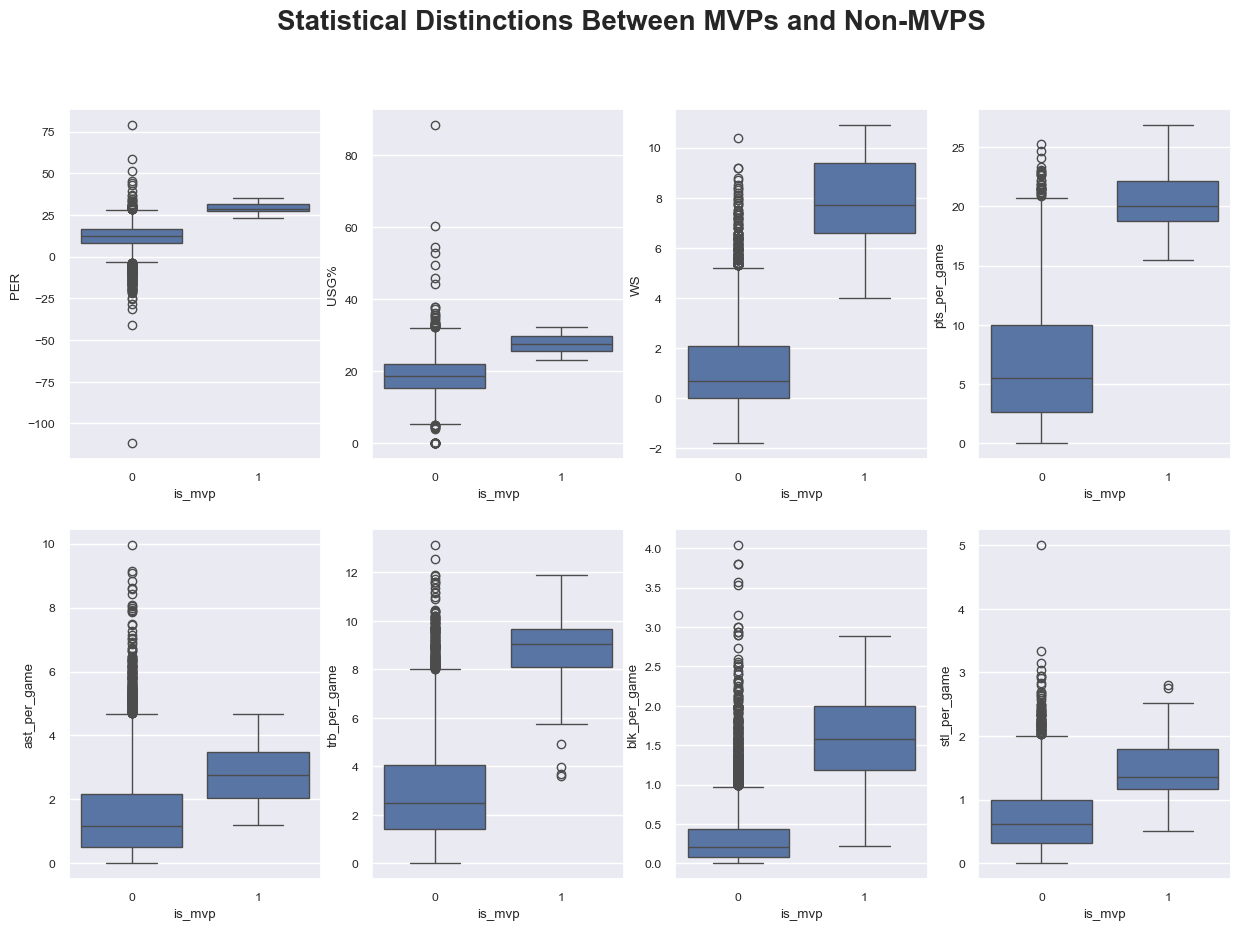

In [72]:
fig, axes = plt.subplots(2, 4, figsize=(15,10))
sns.boxplot(
    data=df,
    x='is_mvp',
    y='PER',
    ax=axes[0,0]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='USG%',
    ax=axes[0,1]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='WS',
    ax=axes[0,2]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='pts_per_game',
    ax=axes[0,3]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='ast_per_game',
    ax=axes[1,0]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='trb_per_game',
    ax=axes[1,1]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='blk_per_game',
    ax=axes[1,2]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='stl_per_game',
    ax=axes[1,3]
)
fig.suptitle('Statistical Distinctions Between MVPs and Non-MVPS', fontsize=20, fontweight='bold')
plt.show()

Most of the non-MVP players fall behind MVPs in all statistical categories but there are also alot high-performing non-MVPs

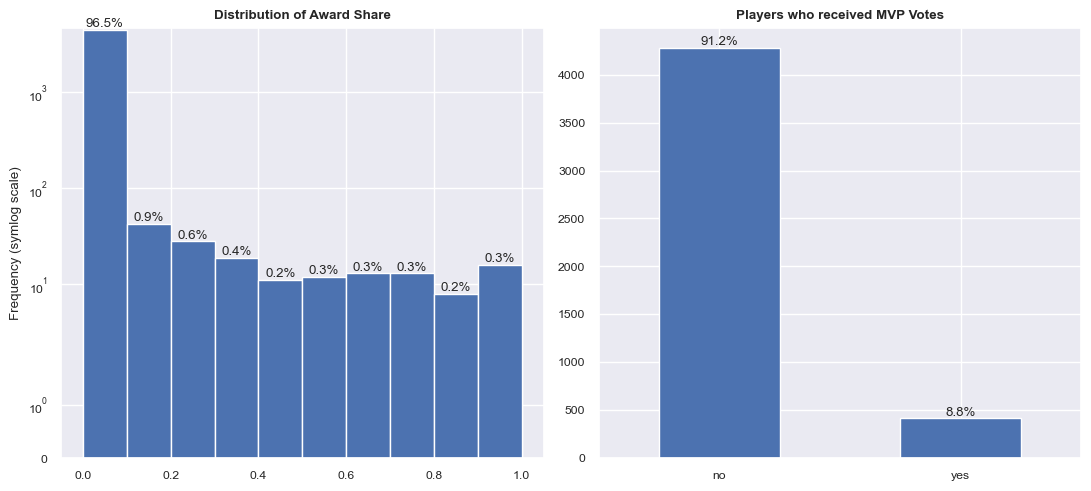

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
total = len(df)

df['award_share'].plot(kind='hist', ax=axes[0])
# Annotate the bars
for p in axes[0].patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()                 
    
    axes[0].annotate(percentage, (x, y), ha='center', va='bottom')
axes[0].set_title("Distribution of Award Share", fontweight='bold')
axes[0].set_yscale('symlog')
axes[0].set_ylabel("Frequency (symlog scale)") 

pie_series = pd.Series(np.where(df['award_share'] > 0, 'yes', 'no'))

pie_series.value_counts().plot(kind='bar', ax=axes[1])


for p in axes[1].patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()                 
    
    axes[1].annotate(percentage, (x, y), ha='center', va='bottom')

axes[1].set_title('Players who received MVP Votes', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

the vast majority of the league (96.5%) receives exactly 0.0 award shares. This insight justifies abandoning standard binary classification.

In [15]:
X = df.drop(columns=['Season','Player','is_mvp', 'award_share'])

X_standardized = StandardScaler().fit_transform(X)
X_standardized.shape

(4691, 10)

In [16]:
tsne = TSNE(n_components=2, random_state=0)
tsne_X = tsne.fit_transform(X_standardized)
tsne_X

array([[-59.381123  ,  10.950104  ],
       [  0.44379595, -30.431894  ],
       [-49.65098   ,  -4.2110395 ],
       ...,
       [-37.842297  , -29.316021  ],
       [-32.333466  , -19.003181  ],
       [  3.402483  ,  27.515305  ]], shape=(4691, 2), dtype=float32)

In [17]:
tsne_df = pd.DataFrame(data=tsne_X, columns=["Dim_1", "Dim_2"])
tsne_df['is_mvp'] = df['is_mvp'].values
tsne_df['award_share'] = df['award_share'].values

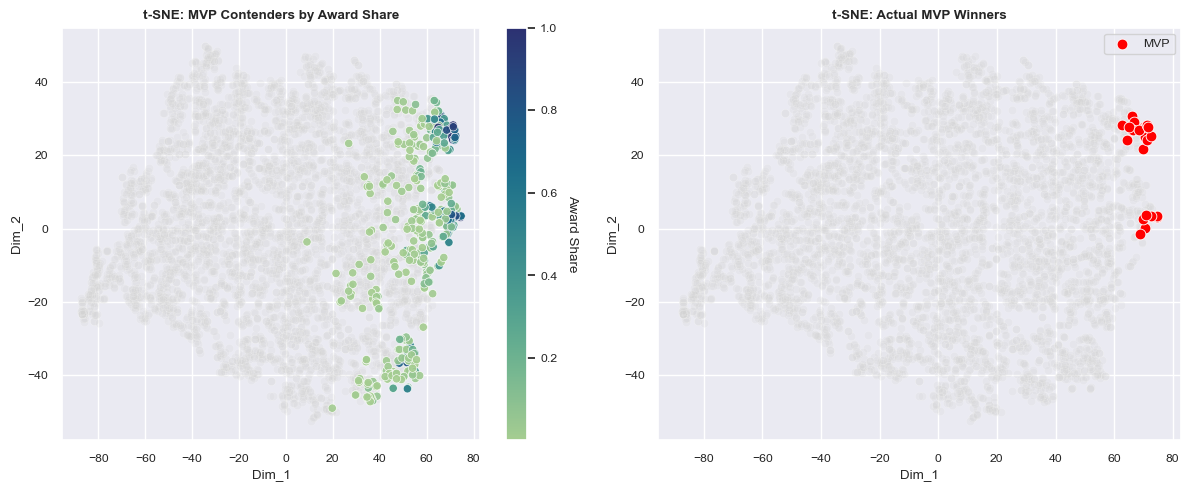

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Layer 1: The Zeros
sns.scatterplot(
    data=tsne_df[tsne_df['award_share'] == 0], 
    x='Dim_1', y='Dim_2', 
    color='lightgrey', 
    alpha=0.2, 
    ax=axes[0],
)

# Layer 2: The Contenders 
sns.scatterplot(
    data=tsne_df[tsne_df['award_share'] > 0], 
    x='Dim_1', y='Dim_2', 
    hue='award_share', 
    palette='crest', 
    alpha=0.9, 
    ax=axes[0],
    legend=False 
)

# Continuous Colorbar
min_vote = tsne_df[tsne_df['award_share'] > 0]['award_share'].min()
norm = Normalize(vmin=min_vote, vmax=1)

# a ScalarMappable object using chosen palette and normalizer
sm = plt.cm.ScalarMappable(cmap='crest', norm=norm)
sm.set_array([])

# 4. Attach the colorbar to the first subplot
cbar = fig.colorbar(sm, ax=axes[0])
cbar.set_label('Award Share', rotation=270, labelpad=15) # Add a nice label

axes[0].set_title("t-SNE: MVP Contenders by Award Share", fontweight='bold')


# Plot 2: is_mvp 
sns.scatterplot(
    data=tsne_df[tsne_df['is_mvp'] == 0], 
    x='Dim_1', y='Dim_2', color='lightgrey', alpha=0.2, ax=axes[1]
)

sns.scatterplot(
    data=tsne_df[tsne_df['is_mvp'] == 1], 
    x='Dim_1', y='Dim_2', color='red', alpha=1.0, s=60, ax=axes[1], label='MVP'
)
axes[1].set_title("t-SNE: Actual MVP Winners", fontweight='bold')

plt.tight_layout()
plt.show()

revealed a distinct "elite cluster." But of because some high-performing non-MVPs merge into that cluster, the visualization confirms that standard metrics alone cannot flawlessly isolate an MVP without a sophisticated gradient boosting approach.

normalize features within season
What actually determines MVP voting is how dominant a player was relative to her peers that year — not her raw numbers.

In [82]:
season_cols = ['TS%', 'WS', 'PER', 'USG%', 'pts_per_game', 'ast_per_game',
               'trb_per_game', 'blk_per_game', 'stl_per_game'] # plus minus is a season total, not a per-game rate

for col in season_cols:
    df[f'{col}_z'] = df.groupby('Season')[col].transform(
        lambda x: (x - x.mean()) / x.std()
    )

df_sorted = df.sort_values(by=['Season', 'Player']).reset_index(drop=True)

features = ['TS%_z', 'WS_z', 'PER_z', 'USG%_z','pts_per_game_z', 'ast_per_game_z',
             'trb_per_game_z', 'blk_per_game_z','stl_per_game_z']
target = 'award_share'

def walk_forward_validation(estimator,features=features,target=target ,df=df,start_test_year=1999, end_test_year=2025):
    yearly_r2 = {}
    yearly_rmse = {}
    all_model_predictions = []

    for test_year in range(start_test_year, end_test_year+1):
        
        train_data = df[df['Season'] < test_year]
        test_data = df[df['Season'] == test_year]

        X_train, y_train = train_data[features], train_data[target]
        X_test, y_test = test_data[features], test_data[target]
        
        estimator.fit(X_train, y_train)
        
        y_pred = estimator.predict(X_test)

        eval_df = pd.DataFrame({
            'Season': test_data['Season'].values,
            'Player': test_data['Player'].values,
            'Actual_Share': y_test.values,
            'Prediction': y_pred
        })
    
        eval_df['Prediction'] = eval_df['Prediction'].clip(lower=0)
        all_model_predictions.append(eval_df)

        r2 = r2_score(y_test, y_pred)
        rmse = mean_squared_error(y_test, y_pred)**(1/2)

        yearly_r2[test_year] = r2
        yearly_rmse[test_year] = rmse
    
    final_predictions_df = pd.concat(all_model_predictions, ignore_index=True)
    overall_r2 = sum(yearly_r2.values())/len(yearly_r2)
    overall_rmse = sum(yearly_rmse.values())/len(yearly_rmse)
    
    return {'overall_r2':overall_r2, 'overall_rmse':overall_rmse, 'final_predictions':final_predictions_df}

In [26]:
raw_features = ['TS%', 'WS', 'PER', 'USG%', 'pts_per_game',
                'ast_per_game', 'trb_per_game', 'blk_per_game', 'stl_per_game']

z_features = ['TS%_z', 'WS_z', 'PER_z', 'USG%_z', 'pts_per_game_z',
              'ast_per_game_z', 'trb_per_game_z', 'blk_per_game_z', 'stl_per_game_z']

default_params = dict(loss_function='RMSE', random_state=0, verbose=0)  # identical params both runs

raw_results = walk_forward_validation(
    catboost.CatBoostRegressor(**default_params), raw_features, target, df_sorted
)
z_results = walk_forward_validation(
    catboost.CatBoostRegressor(**default_params), z_features, target, df_sorted
)

print("Raw R²:", raw_results['overall_r2'])
print("Season-normalized R²:", z_results['overall_r2'])

Raw R²: 0.6461307708148892
Season-normalized R²: 0.686181806998142


Quick comparison for CatBoost model performnace using standard features vs raw features, 

In [94]:
from scipy.stats import spearmanr
baseline_corr = spearmanr(df['WS'], df['award_share'])
baseline_corr

SignificanceResult(statistic=np.float64(0.4468678023544195), pvalue=np.float64(4.015317217985721e-229))

In [83]:
def get_comparison_table(results_df):
    sorted_preds = results_df.sort_values(
    by=['Season', 'Prediction'], 
    ascending=[True, False]
    )
    predicted_mvps = sorted_preds.groupby('Season').head(1).reset_index(drop=True)

    actual_mvps = results_df.sort_values(
        by=['Season','Actual_Share'], ascending=[True, False]
    ).groupby('Season').head(1)[['Season','Player']].rename(columns={'Player':'Actual_MVP'})

    return predicted_mvps.rename(
        columns={'Player':'Predicted_MVP'}
        ).merge(actual_mvps, on='Season')

Are win shares enough to predict MVP?

In [92]:
single_feature_results = walk_forward_validation(
    estimator=catboost.CatBoostRegressor(iterations=300, learning_rate=0.05, verbose=0, random_state=0),
    features=['WS_z'], start_test_year=2013
)

print("R_2:", single_feature_results['overall_r2'])
print("Rmse:", single_feature_results['overall_rmse'])

single_feature_comparison = get_comparison_table(single_feature_results['final_predictions'])
single_feature_comparison

R_2: 0.6759864513826883
Rmse: 0.05541965906550584


,Season,Predicted_MVP,Actual_Share,Prediction,Actual_MVP
0,2013,Maya Moore,0.623,0.548018,Candace Parker
1,2014,Maya Moore,0.976,0.712656,Maya Moore
2,2015,Elena Delle Donne,0.987,0.730230,Elena Delle Donne
3,2016,Nneka Ogwumike,0.928,0.751999,Nneka Ogwumike
4,2017,Sylvia Fowles,0.962,0.765307,Sylvia Fowles
5,2018,Breanna Stewart,0.954,0.530793,Breanna Stewart
6,2019,Elena Delle Donne,0.977,0.779246,Elena Delle Donne
7,2020,Breanna Stewart,0.655,0.352312,A'ja Wilson
8,2021,Jonquel Jones,0.994,0.607165,Jonquel Jones
9,2022,Breanna Stewart,0.796,0.633262,A'ja Wilson


In [ ]:
def xgb_objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'eta': trial.suggest_float('eta', 0.01, 0.15, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'random_state': 0,
    }
    results = walk_forward_validation(
        estimator=xgboost.XGBRegressor(**params),
        features=features, target=target, df=df_sorted,
        start_test_year=2013, end_test_year=2025
    )
    return results['overall_r2']

In [45]:
study = optuna.create_study(direction='maximize')
study.optimize(xgb_objective, n_trials=40)
print(study.best_params, study.best_value)

[I 2026-06-21 13:05:52,678] A new study created in memory with name: no-name-28582e14-41df-4749-825e-89a281732047
[I 2026-06-21 13:06:04,547] Trial 0 finished with value: 0.7268985721438249 and parameters: {'max_depth': 8, 'eta': 0.03948444967277224, 'n_estimators': 737, 'subsample': 0.6064460767309883}. Best is trial 0 with value: 0.7268985721438249.
[I 2026-06-21 13:06:14,778] Trial 1 finished with value: 0.7307421886127579 and parameters: {'max_depth': 7, 'eta': 0.026102842239189357, 'n_estimators': 772, 'subsample': 0.6625486264912088}. Best is trial 1 with value: 0.7307421886127579.
[I 2026-06-21 13:06:19,919] Trial 2 finished with value: 0.7279623926479024 and parameters: {'max_depth': 8, 'eta': 0.06745713360726653, 'n_estimators': 550, 'subsample': 0.8349041839964622}. Best is trial 1 with value: 0.7307421886127579.
[I 2026-06-21 13:06:21,897] Trial 3 finished with value: 0.7054851367573558 and parameters: {'max_depth': 3, 'eta': 0.052720286137911576, 'n_estimators': 381, 'subsa

{'max_depth': 4, 'eta': 0.012364318721607502, 'n_estimators': 509, 'subsample': 0.6646588726735754} 0.7473962799909065


In [ ]:
def catb_objective(trial):
    params = {
        'depth': trial.suggest_int('depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'iterations': trial.suggest_int('iterations', 200, 800),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'loss_function': 'RMSE',
        'random_state': 0,
        'verbose': 0,
    }
    results = walk_forward_validation(
        estimator=catboost.CatBoostRegressor(**params),
        features=features, target=target, df=df_sorted,
        start_test_year=2013, end_test_year=2025 
    )
    return results['overall_r2']

study2 = optuna.create_study(direction='maximize')
study2.optimize(catb_objective, n_trials=40)
print(study2.best_params, study2.best_value)

[I 2026-06-21 00:42:13,639] A new study created in memory with name: no-name-33bbd015-5c3a-47e3-a534-0890583a1b66
[I 2026-06-21 00:42:20,479] Trial 0 finished with value: 0.7237090627451229 and parameters: {'depth': 3, 'learning_rate': 0.061053335048500315, 'iterations': 381, 'l2_leaf_reg': 7.054891315771352}. Best is trial 0 with value: 0.7237090627451229.
[I 2026-06-21 00:42:29,395] Trial 1 finished with value: 0.7347075785112464 and parameters: {'depth': 4, 'learning_rate': 0.016060502371462435, 'iterations': 451, 'l2_leaf_reg': 7.254422711740724}. Best is trial 1 with value: 0.7347075785112464.
[I 2026-06-21 00:42:37,191] Trial 2 finished with value: 0.7153441466313714 and parameters: {'depth': 4, 'learning_rate': 0.07218292651117546, 'iterations': 386, 'l2_leaf_reg': 4.4905648225503745}. Best is trial 1 with value: 0.7347075785112464.
[I 2026-06-21 00:42:49,434] Trial 3 finished with value: 0.7306763200900426 and parameters: {'depth': 7, 'learning_rate': 0.049229344630469435, 'ite

{'depth': 3, 'learning_rate': 0.024500159421583276, 'iterations': 277, 'l2_leaf_reg': 5.610492949525419} 0.738199112539097


In [ ]:
def lightgbm_objective(trial):
    params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': trial.suggest_int('num_leaves', 63, 127),
    'learning_rate': trial.suggest_float('learning_rate', 0.01,0.05),
    'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 0.7),
    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.7),
    'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
    'random_state':0,
    'verbose':-1
    }
    results = walk_forward_validation(
        estimator=lightgbm.LGBMRegressor(**params),
        features=features,target=target, df=df_sorted,
        start_test_year=2013,end_test_year=2025 
    )
    return results['overall_r2']

study3 = optuna.create_study(direction='maximize')
study3.optimize(lightgbm_objective, n_trials=40)
print(study3.best_params, study3.best_value)

[I 2026-06-21 12:48:27,056] A new study created in memory with name: no-name-6fb9cc43-e811-4d78-a0a3-843076210113
[I 2026-06-21 12:48:29,315] Trial 0 finished with value: 0.585101062732655 and parameters: {'num_leaves': 106, 'learning_rate': 0.01020252954764032, 'feature_fraction': 0.6544281617937594, 'colsample_bytree': 0.6580896514193618, 'min_child_samples': 20}. Best is trial 0 with value: 0.585101062732655.
[I 2026-06-21 12:48:31,260] Trial 1 finished with value: 0.7222550757382111 and parameters: {'num_leaves': 107, 'learning_rate': 0.04667139352785764, 'feature_fraction': 0.6291646858711296, 'colsample_bytree': 0.6482120147980323, 'min_child_samples': 31}. Best is trial 1 with value: 0.7222550757382111.
[I 2026-06-21 12:48:32,660] Trial 2 finished with value: 0.5993362691485492 and parameters: {'num_leaves': 73, 'learning_rate': 0.015582024971508731, 'feature_fraction': 0.6906594049571348, 'colsample_bytree': 0.6247449533767624, 'min_child_samples': 50}. Best is trial 1 with val

{'num_leaves': 90, 'learning_rate': 0.03798712141324875, 'feature_fraction': 0.6223499378819357, 'colsample_bytree': 0.6130319548715177, 'min_child_samples': 21} 0.736595348957186


In [81]:
def walk_forward_validation_ranker(estimator, features=features, target=target, df=df_sorted, start_test_year=1999, end_test_year=2025):
    all_preds = []
    hits = []

    for test_year in range(start_test_year, end_test_year + 1):
        train_data = df[df['Season'] < test_year].sort_values('Season')  # must be contiguous by group
        test_data = df[df['Season'] == test_year]

        X_train, y_train = train_data[features], train_data[target]
        X_test, y_test = test_data[features], test_data[target]

        group_sizes = train_data.groupby('Season').size().values

        estimator.fit(X_train, y_train, group=group_sizes)
        y_pred = estimator.predict(X_test)   # raw ranking score — NOT an award_share estimate

        eval_df = pd.DataFrame({
            'Season': test_data['Season'].values,
            'Player': test_data['Player'].values,
            'Actual_Share': y_test.values,
            'Prediction': y_pred
        })
        all_preds.append(eval_df)

        predicted_top = eval_df.loc[eval_df['Prediction'].idxmax(), 'Player']
        actual_top = eval_df.loc[eval_df['Actual_Share'].idxmax(), 'Player']
        hits.append(predicted_top == actual_top)

    final_predictions_df = pd.concat(all_preds, ignore_index=True)
    return {'hit_rate': sum(hits) / len(hits), 'final_predictions': final_predictions_df}

In [ ]:
ranker = xgboost.XGBRanker(objective='rank:pairwise', random_state=0)
ranker_results = walk_forward_validation_ranker(
    estimator=ranker, start_test_year=2015
)

print(f"Top-1 hit rate: {ranker_results['hit_rate']:.2%}")

predicted_mvps_ranker = get_comparison_table(ranker_results['final_predictions'])
predicted_mvps_ranker

Top-1 hit rate: 63.64%


,Season,Predicted_MVP,Actual_Share,Prediction,Actual_MVP
0,2015,Maya Moore,0.631,6.917254,Elena Delle Donne
1,2016,Maya Moore,0.505,5.849581,Nneka Ogwumike
2,2017,Sylvia Fowles,0.962,5.446976,Sylvia Fowles
3,2018,Liz Cambage,0.592,5.677861,Breanna Stewart
4,2019,Elena Delle Donne,0.977,5.336360,Elena Delle Donne
5,2020,Breanna Stewart,0.655,3.992705,A'ja Wilson
6,2021,Jonquel Jones,0.994,5.672103,Jonquel Jones
7,2022,A'ja Wilson,0.854,6.536408,A'ja Wilson
8,2023,Breanna Stewart,0.743,7.229391,Breanna Stewart
9,2024,A'ja Wilson,1.000,6.147622,A'ja Wilson


In [ ]:
catb_bestparams = {'depth': 3, 'learning_rate': 0.024500159421583276, 'iterations': 277, 'l2_leaf_reg': 5.610492949525419}
xgb_bestparams = {'max_depth': 4, 'eta': 0.012364318721607502, 'n_estimators': 509, 'subsample': 0.6646588726735754}
lightgbm_bestparams = {'num_leaves': 90, 'learning_rate': 0.03798712141324875, 'feature_fraction': 0.6223499378819357, 'colsample_bytree': 0.6130319548715177, 'min_child_samples': 21}

catb = catboost.CatBoostRegressor(**study2.best_params, loss_function='RMSE', random_state=0, verbose=0)
xgb = xgboost.XGBRegressor(**study.best_params, random_state=0)
lgbm = lightgbm.LGBMRegressor(**study3.best_params, random_state=0, verbose=-1)

In [85]:
catb_results = walk_forward_validation(
                estimator=catb,
                features=features,
                target=target,
                start_test_year=2013)

print(f'r2: {catb_results['overall_r2']}')
print(f'rmse: {catb_results['overall_rmse']}')

comparison_catb = get_comparison_table(catb_results['final_predictions'])
comparison_catb

r2: 0.7758424493470143
rmse: 0.045551411603168154


,Season,Predicted_MVP,Actual_Share,Prediction,Actual_MVP
0,2013,Candace Parker,0.669,0.372904,Candace Parker
1,2014,Maya Moore,0.976,0.724956,Maya Moore
2,2015,Elena Delle Donne,0.987,0.682714,Elena Delle Donne
3,2016,Nneka Ogwumike,0.928,0.511331,Nneka Ogwumike
4,2017,Nneka Ogwumike,0.222,0.511772,Sylvia Fowles
5,2018,Liz Cambage,0.592,0.727860,Breanna Stewart
6,2019,Elena Delle Donne,0.977,0.646228,Elena Delle Donne
7,2020,Breanna Stewart,0.655,0.418546,A'ja Wilson
8,2021,Jonquel Jones,0.994,0.589312,Jonquel Jones
9,2022,Breanna Stewart,0.796,0.634673,A'ja Wilson


In [86]:
xgb_results = walk_forward_validation(
    estimator=xgb,
    features=features,
    target=target,
    start_test_year=2013
    )

print(f'r2: {xgb_results['overall_r2']}')
print(f'rmse: {xgb_results['overall_rmse']}')

comparison_xgb = get_comparison_table(xgb_results['final_predictions'])
comparison_xgb

r2: 0.7836190653479332
rmse: 0.04450692735171405


,Season,Predicted_MVP,Actual_Share,Prediction,Actual_MVP
0,2013,Diana Taurasi,0.197,0.339441,Candace Parker
1,2014,Maya Moore,0.976,0.747009,Maya Moore
2,2015,Elena Delle Donne,0.987,0.777210,Elena Delle Donne
3,2016,Maya Moore,0.505,0.638878,Nneka Ogwumike
4,2017,Nneka Ogwumike,0.222,0.572192,Sylvia Fowles
5,2018,Liz Cambage,0.592,0.650165,Breanna Stewart
6,2019,Elena Delle Donne,0.977,0.540041,Elena Delle Donne
7,2020,Breanna Stewart,0.655,0.530003,A'ja Wilson
8,2021,Jonquel Jones,0.994,0.624872,Jonquel Jones
9,2022,A'ja Wilson,0.854,0.675320,A'ja Wilson


In [87]:
lgbm_results = walk_forward_validation(
                estimator=lgbm,
                features=features,
                target=target,
                start_test_year=2013)

print(f'r2: {lgbm_results['overall_r2']}')
print(f'rmse: {lgbm_results['overall_rmse']}')

comparison_lgbm = get_comparison_table(lgbm_results['final_predictions'])
comparison_lgbm

r2: 0.7739844002418625
rmse: 0.04568813294594955


,Season,Predicted_MVP,Actual_Share,Prediction,Actual_MVP
0,2013,Candace Parker,0.669,0.389199,Candace Parker
1,2014,Maya Moore,0.976,0.576557,Maya Moore
2,2015,Elena Delle Donne,0.987,0.627077,Elena Delle Donne
3,2016,Maya Moore,0.505,0.518589,Nneka Ogwumike
4,2017,Sylvia Fowles,0.962,0.519260,Sylvia Fowles
5,2018,Breanna Stewart,0.954,0.618179,Breanna Stewart
6,2019,Elena Delle Donne,0.977,0.680504,Elena Delle Donne
7,2020,Breanna Stewart,0.655,0.446656,A'ja Wilson
8,2021,Jonquel Jones,0.994,0.536765,Jonquel Jones
9,2022,A'ja Wilson,0.854,0.609577,A'ja Wilson


In [96]:
def topk_hit_rate(predictions_df, k=3, score_col='Prediction'):
    hits = []
    for season, group in predictions_df.groupby('Season'):
        top_k = group.sort_values(score_col, ascending=False).head(k)['Player']
        actual_mvp = group.sort_values('Actual_Share', ascending=False).iloc[0]['Player']
        hits.append(actual_mvp in top_k.values)
    return sum(hits) / len(hits)

k=2
print(f"CatBoost on Win Shares only hit@{k}:", topk_hit_rate(single_feature_results['final_predictions'], k=k))
print(f"CatBoost hit@{k}:", topk_hit_rate(catb_results['final_predictions'], k=k))
print(f"LightGBM hit@{k}:", topk_hit_rate(lgbm_results['final_predictions'], k=k))
print(f"XGBoost hit@{k}:", topk_hit_rate(xgb_results['final_predictions'], k=k))
print(f"Ranker hit@{k}:  ", topk_hit_rate(ranker_results['final_predictions'], k=k, score_col='Prediction'))

CatBoost on Win Shares only hit@2: 0.8461538461538461
CatBoost hit@2: 1.0
LightGBM hit@2: 1.0
XGBoost hit@2: 0.9230769230769231
Ranker hit@2:   0.9090909090909091


Text(0.5, 1.0, 'XGBoost Regressor Model')

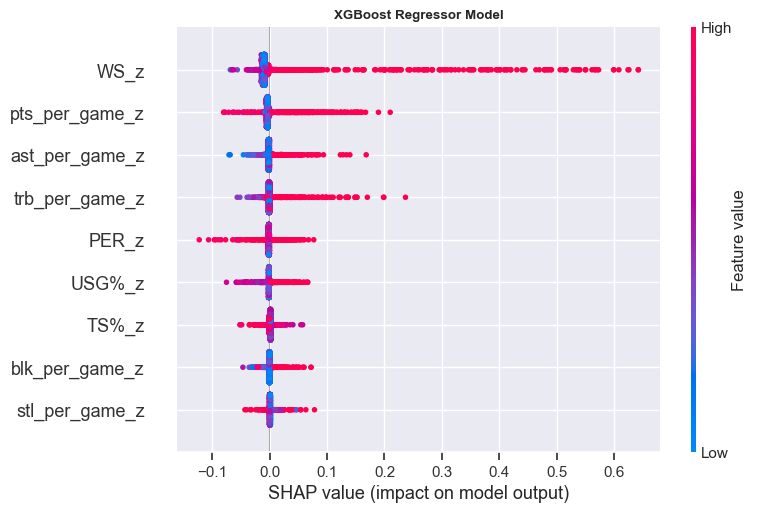

In [56]:
xgb_explainer = shap.TreeExplainer(xgb)
xgb_shap_values = xgb_explainer(df[features])
shap.summary_plot(xgb_shap_values, df[features], show=False)
plt.title("XGBoost Regressor Model", fontweight='bold')

Text(0.5, 1.0, 'CATBoost Regressor Model')

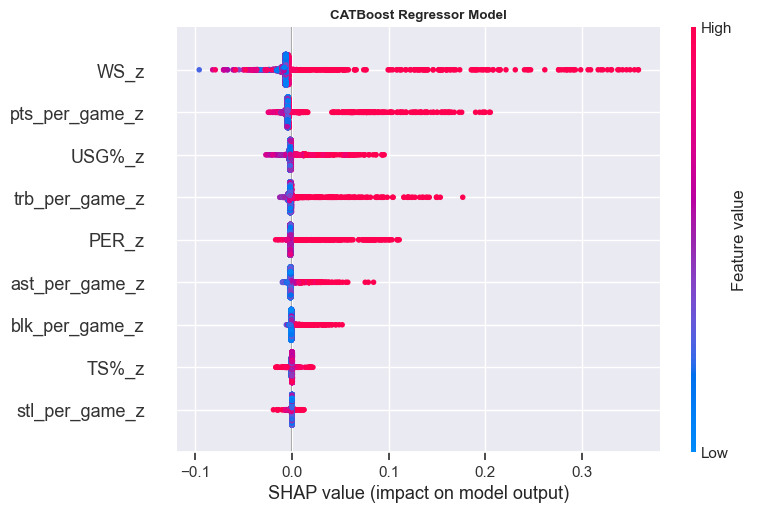

In [57]:
explainer = shap.TreeExplainer(catb)
shap_values = explainer(df[features])

shap.summary_plot(shap_values, df[features], show=False)
plt.title("CATBoost Regressor Model", fontweight='bold')

Text(0.5, 1.0, 'LightGBM Regressor Model')

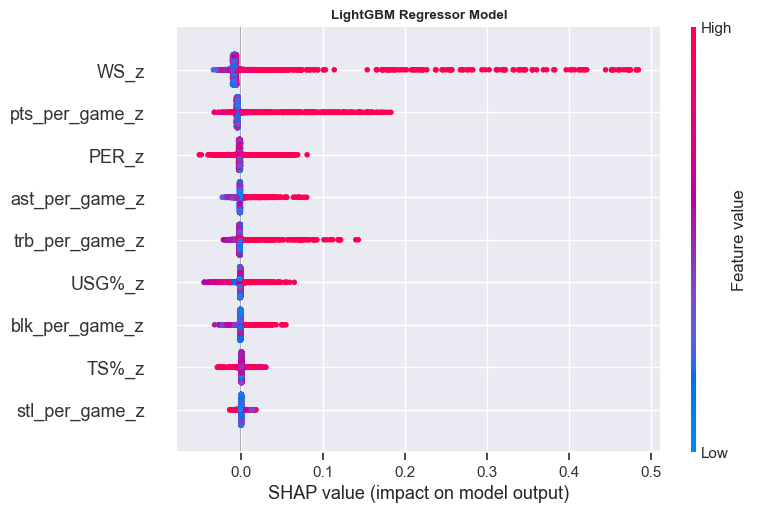

In [58]:
lightgbm_explainer = shap.TreeExplainer(lgbm)
lightgbm_shap_values = lightgbm_explainer(df[features])
shap.summary_plot(lightgbm_shap_values, df[features], show=False)
plt.title("LightGBM Regressor Model", fontweight='bold')

Text(0.5, 1.0, 'XGBoost Ranker Model')

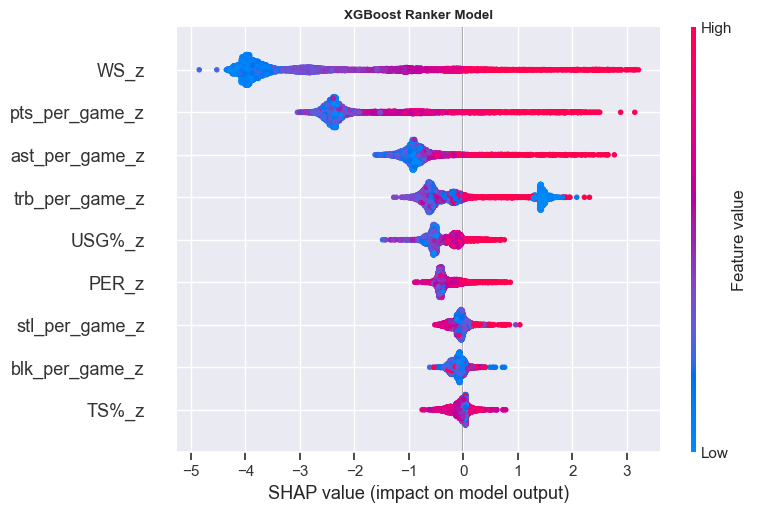

In [59]:
xgbranker_explainer = shap.TreeExplainer(ranker)
xgbranker_shap_values = xgbranker_explainer(df[features])
shap.summary_plot(xgbranker_shap_values, df[features], show=False)
plt.title("XGBoost Ranker Model", fontweight='bold')

In [60]:
# WS-only across the FULL, harder historical range — the missing half of the picture
single_feature_full = walk_forward_validation(
    estimator=catboost.CatBoostRegressor(iterations=300, learning_rate=0.05, verbose=0, random_state=0),
    features=['WS_z'], target=target, df=df_sorted
    # default start_test_year=1999
)
print("WS-only hit@1 (1999–2025):", topk_hit_rate(single_feature_full['final_predictions'], k=1))
print("WS-only hit@3 (1999–2025):", topk_hit_rate(single_feature_full['final_predictions'], k=3))

# Ranker on the SAME recent window as everything else in this comparison
ranker_recent = walk_forward_validation_ranker(
    estimator=xgboost.XGBRanker(objective='rank:pairwise', random_state=0),
    df=df_sorted, start_test_year=2015
)
print("Ranker hit@1 (2015–2025):", ranker_recent['hit_rate'])
print("Ranker hit@3 (2015–2025):", topk_hit_rate(ranker_recent['final_predictions'], k=3, score_col='Predicted_Score'))

WS-only hit@1 (1999–2025): 0.5555555555555556
WS-only hit@3 (1999–2025): 0.8148148148148148
Ranker hit@1 (2015–2025): 0.6363636363636364
Ranker hit@3 (2015–2025): 0.9090909090909091


In [100]:
def walk_forward_ensemble(estimators, features=features, target=target, df=df_sorted, start_test_year=1999, end_test_year=2025):
    all_preds = []
    for test_year in range(start_test_year, end_test_year + 1):
        train_data = df[df['Season'] < test_year]
        test_data = df[df['Season'] == test_year]
        X_train, y_train = train_data[features], train_data[target]
        X_test, y_test = test_data[features], test_data[target]

        preds = {}
        for name, est in estimators.items():
            est.fit(X_train, y_train)
            preds[name] = np.clip(est.predict(X_test), 0, None)

        ensemble_pred = np.mean(list(preds.values()), axis=0)

        all_preds.append(pd.DataFrame({
            'Season': test_data['Season'].values,
            'Player': test_data['Player'].values,
            'Actual_Share': y_test.values,
            'Prediction': ensemble_pred
        }))

    final_predictions_df = pd.concat(all_preds, ignore_index=True)
    return {
        'overall_r2': r2_score(final_predictions_df['Actual_Share'], final_predictions_df['Prediction']),
        'overall_rmse': mean_squared_error(final_predictions_df['Actual_Share'], final_predictions_df['Prediction'])**0.5,
        'final_predictions': final_predictions_df
    }

ensemble_results = walk_forward_ensemble(
    estimators={
        'catb': catboost.CatBoostRegressor(**catb_bestparams, loss_function='RMSE', random_state=0, verbose=0),
        'xgb':  xgboost.XGBRegressor(**xgb_bestparams, random_state=0),
        'lgbm': lightgbm.LGBMRegressor(**lightgbm_bestparams, random_state=0, verbose=-1),
    },
    start_test_year=2013
)

print("Ensemble R²:", ensemble_results['overall_r2'])
print("Ensemble hit@1:", topk_hit_rate(ensemble_results['final_predictions'], k=1))
print("Ensemble hit@3:", topk_hit_rate(ensemble_results['final_predictions'], k=3))

Ensemble R²: 0.7898310401023735
Ensemble hit@1: 0.6153846153846154
Ensemble hit@3: 1.0
